In [7]:
# !wget https://www.dropbox.com/scl/fi/pjiets75ek3lflqh4yrdz/dataset.zip?rlkey=o0vwk214f902cs3w4b079vbz9&st=fipo0beb&dl=0

# !mv dataset.zip?rlkey=o0vwk214f902cs3w4b079vbz9 dataset.zip

# !unzip dataset.zip

# !rm dataset.zip

In [8]:
# [colab] Setup & scan
import os, re, random, time, math, numpy as np
from pathlib import Path
import pandas as pd
from PIL import Image, UnidentifiedImageError

import torch, torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from sklearn.preprocessing import LabelEncoder

# Set random seed for reproducibility
SEED = 2025
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# Fixed paths
ROOT = Path("/content/dataset")
TRAIN_DIR = ROOT/"training"
VAL_DIR   = ROOT/"validation"
TEST_DIR  = ROOT/"test"
CSV_PATH  = ROOT/"label.csv"

assert TRAIN_DIR.is_dir() and VAL_DIR.is_dir() and TEST_DIR.is_dir(), "Missing data directories"
assert CSV_PATH.is_file(), "label.csv not found"
print("Dirs OK:", TRAIN_DIR, VAL_DIR, TEST_DIR)

# Read CSV (two columns: Image ID, Image class)
df = pd.read_csv(CSV_PATH)
id_col  = [c for c in df.columns if c.strip().lower()=="image id"]
cls_col = [c for c in df.columns if c.strip().lower()=="image class"]
if not id_col or not cls_col:
    raise ValueError(f"CSV must contain columns: 'Image ID' and 'Image class'. Current columns: {list(df.columns)}")

df = df.rename(columns={id_col[0]: "image_id", cls_col[0]: "image_class"})
df["image_id"] = df["image_id"].astype(str).str.strip()
# Allow IDs like '001', 'ID-12', etc.; extract the digits as the numeric ID
df["image_id_num"] = df["image_id"].str.extract(r"(\d+)").astype(int)

id2class = dict(zip(df["image_id_num"], df["image_class"]))
print(f"[CSV] rows: {len(df)}, class samples: {df['image_class'].unique()[:8]}")

# Scan images
IMG_EXTS = {".png", ".jpg", ".jpeg", ".bmp", ".tif", ".tiff"}
def list_images(folder: Path):
    return [p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS]

train_imgs = list_images(TRAIN_DIR)
val_imgs   = list_images(VAL_DIR)
test_imgs  = list_images(TEST_DIR)

# Extract numeric ID from filename/path (prefer stem; if not found, fallback to the last number in the path)
_digit_pat = re.compile(r"(\d+)")
def extract_id_from_path(p: Path):
    m = _digit_pat.search(p.stem)
    if m: return int(m.group(1))
    all_nums = _digit_pat.findall(str(p))
    return int(all_nums[-1]) if all_nums else None

# Audit matching
def audit_split(imgs, name):
    total, ok = len(imgs), 0
    miss = []
    for p in imgs:
        iid = extract_id_from_path(p)
        if iid is not None and iid in id2class:
            ok += 1
        else:
            miss.append(str(p.relative_to(ROOT)))
    print(f"[{name}] images={total}, matched labels={ok}, unmatched={total-ok}")
    if miss[:10]:
        print("  Unmatched examples:", miss[:10])

audit_split(train_imgs, "training")
audit_split(val_imgs,   "validation")
print(f"[test] images={len(test_imgs)} (no labels expected)")

# Fit LabelEncoder (based on labels matched in train+val)
train_classes = [id2class.get(extract_id_from_path(p)) for p in train_imgs]
val_classes   = [id2class.get(extract_id_from_path(p)) for p in val_imgs]
all_classes   = [c for c in (train_classes+val_classes) if c is not None]
if not all_classes:
    raise RuntimeError("No labels matched in training/validation. Please check filename ↔ CSV ID mapping.")

le = LabelEncoder().fit(all_classes)
NUM_CLASSES = len(le.classes_)
print("NUM_CLASSES =", NUM_CLASSES, "| classes preview:", le.classes_[:8])

Dirs OK: /content/dataset/training /content/dataset/validation /content/dataset/test
[CSV] rows: 13596, class samples: ['Homogeneous' 'Speckled' 'Nucleolar' 'Centromere' 'NuMem' 'Golgi']
[training] images=8701, matched labels=8701, unmatched=0
[validation] images=2175, matched labels=2175, unmatched=0
[test] images=2720 (no labels expected)
NUM_CLASSES = 6 | classes preview: ['Centromere' 'Golgi' 'Homogeneous' 'NuMem' 'Nucleolar' 'Speckled']


In [9]:
from typing import Tuple, List, Optional
from pathlib import Path
import time, gc
import torch
from torchvision import transforms
from torch.utils.data import Dataset, DataLoader
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True  # Try not to fail on truncated/corrupted images

# --- Transforms: grayscale -> 3 channels, resize to 224, normalize only ---
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# --- Choose exactly one interpolation per run ---
# Options: "nearest" / "bilinear" / "bicubic"
INTERP_NAME = "bicubic"   # change here for ablations

def _interp_from_name(name: str) -> transforms.InterpolationMode:
    name = name.lower()
    if name == "nearest":
        return transforms.InterpolationMode.NEAREST
    elif name == "bilinear":
        return transforms.InterpolationMode.BILINEAR
    elif name == "bicubic":
        return transforms.InterpolationMode.BICUBIC
    else:
        raise ValueError(f"Unknown interp: {name}")

def make_tfms_tensor_resize(interp_name: str):
    """
    Build a single transform pipeline using a chosen interpolation.
    NOTE:
    - We convert to Tensor BEFORE Resize so that interpolation happens on tensors,
      where we can explicitly control 'antialias' and avoid PIL warnings.
    - For non-NEAREST, we explicitly set antialias=False to keep behavior consistent
      across torchvision versions (and match your requirement).
    """
    interp = _interp_from_name(interp_name)
    resize_kwargs = {"size": (224, 224), "interpolation": interp}
    if interp != transforms.InterpolationMode.NEAREST:
        resize_kwargs["antialias"] = False  # explicitly disable

    return transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),                 # Tensor first -> Resize on tensor
        transforms.Resize(**resize_kwargs),    # same interp for all runs; no PIL antialias
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
    ])

# ---- Build transforms for the selected interpolation (run one at a time) ----
base_tfms = make_tfms_tensor_resize(INTERP_NAME)

# --- Keep only samples whose numeric ID is in filename AND found in CSV labels ---
def filter_matched(paths: List[Path]):
    kept, dropped = [], []
    for p in paths:
        iid = extract_id_from_path(p)      # depends on your helper defined earlier
        cls = id2class.get(iid, None)      # depends on your id2class mapping
        if iid is not None and cls is not None:
            kept.append(p)
        else:
            dropped.append(p)
    return kept, dropped

train_imgs_kept, train_dropped = filter_matched(train_imgs)  # depends on train_imgs
val_imgs_kept,   val_dropped   = filter_matched(val_imgs)    # depends on val_imgs
print(f"[filter] train kept={len(train_imgs_kept)} dropped={len(train_dropped)} | "
      f"val kept={len(val_imgs_kept)} dropped={len(val_dropped)}")

# --- Datasets (train/val: labeled; test: unlabeled) ---
class LabeledFromCSV(Dataset):
    def __init__(self, paths: List[Path], id2class: dict, label_encoder, transform=None):
        self.paths = paths
        self.id2class = id2class
        self.le = label_encoder
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, int]:
        p = self.paths[idx]
        # Use context manager to promptly close file handles (prevents worker hangs)
        with Image.open(p) as im:
            img = im.convert("L")
        if self.transform:
            img = self.transform(img)
        iid = extract_id_from_path(p)
        cls_str = self.id2class[iid]
        y = int(self.le.transform([cls_str])[0])
        return img, y

class TestImageDataset(Dataset):
    def __init__(self, paths: List[Path], transform=None):
        self.paths = paths
        self.transform = transform

    def __len__(self): return len(self.paths)

    def __getitem__(self, idx: int) -> Tuple[torch.Tensor, str]:
        p = self.paths[idx]
        with Image.open(p) as im:
            img = im.convert("L")
        if self.transform:
            img = self.transform(img)
        rel = str(p.relative_to(TEST_DIR))  # depends on TEST_DIR
        return img, rel

train_ds = LabeledFromCSV(train_imgs_kept, id2class, le, transform=base_tfms)
val_ds   = LabeledFromCSV(val_imgs_kept,   id2class, le, transform=base_tfms)
test_ds  = TestImageDataset(test_imgs, transform=base_tfms)

# --- DataLoaders (stable 4-worker setup) ---
BATCH_SIZE   = 64     # Adjust for memory at 224×224 (e.g., 32/64/128)
NUM_WORKERS  = 4
PIN_MEMORY   = torch.cuda.is_available()
PERSISTENT   = True   # Reuse workers after the first epoch
PREFETCH     = 2
TIMEOUT_SEC  = 60     # Fail fast if any worker stalls

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC, drop_last=False
)
val_loader = DataLoader(
    val_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC
)
test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
    persistent_workers=PERSISTENT, prefetch_factor=PREFETCH,
    timeout=TIMEOUT_SEC
)

# --- One-shot sanity check (surface potential stalls/bad images early) ---
t0 = time.time()
xb, yb = next(iter(train_loader))
xv, yv = next(iter(val_loader))
xt, names = next(iter(test_loader))
print(f"[interp={INTERP_NAME}] Train batch:", xb.shape, yb.shape)  # [B, 3, 224, 224], [B]
print(f"[interp={INTERP_NAME}] Val   batch:", xv.shape, yv.shape)
print(f"[interp={INTERP_NAME}] Test  batch:", xt.shape, len(names), names[:3])
print(f"[sanity] fetched first batches in {time.time()-t0:.2f}s")

# Class names (aligned with LabelEncoder)
classes = list(le.classes_)
idx_to_class = {i: c for i, c in enumerate(classes)}
print("NUM_CLASSES =", len(classes))
print("Class preview:", classes[:8])


[filter] train kept=8701 dropped=0 | val kept=2175 dropped=0
[interp=bicubic] Train batch: torch.Size([64, 3, 224, 224]) torch.Size([64])
[interp=bicubic] Val   batch: torch.Size([64, 3, 224, 224]) torch.Size([64])
[interp=bicubic] Test  batch: torch.Size([64, 3, 224, 224]) 64 ['07205.png', '09646.png', '11204.png']
[sanity] fetched first batches in 1.50s
NUM_CLASSES = 6
Class preview: [np.str_('Centromere'), np.str_('Golgi'), np.str_('Homogeneous'), np.str_('NuMem'), np.str_('Nucleolar'), np.str_('Speckled')]


In [10]:
import torch
import torch.nn as nn
from torchvision.models import alexnet, AlexNet_Weights

device = "cuda" if torch.cuda.is_available() else "cpu"
NUM_CLASSES = 6

model = alexnet(weights=None)
in_features = model.classifier[-1].in_features
model.classifier[-1] = nn.Linear(in_features, NUM_CLASSES)

nn.init.xavier_uniform_(model.classifier[-1].weight)
nn.init.zeros_(model.classifier[-1].bias)

model = model.to(device)
print(model.classifier)


Sequential(
  (0): Dropout(p=0.5, inplace=False)
  (1): Linear(in_features=9216, out_features=4096, bias=True)
  (2): ReLU(inplace=True)
  (3): Dropout(p=0.5, inplace=False)
  (4): Linear(in_features=4096, out_features=4096, bias=True)
  (5): ReLU(inplace=True)
  (6): Linear(in_features=4096, out_features=6, bias=True)
)


In [11]:
print(model)

AlexNet(
  (features): Sequential(
    (0): Conv2d(3, 64, kernel_size=(11, 11), stride=(4, 4), padding=(2, 2))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(64, 192, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(192, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): ReLU(inplace=True)
    (10): Conv2d(256, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (11): ReLU(inplace=True)
    (12): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (avgpool): AdaptiveAvgPool2d(output_size=(6, 6))
  (classifier): Sequential(
    (0): Dropout(p=0.5, inplace=False)
    (1): Linear(in_features=9216, out_features=4096, bias=True)
 

Train 001/100:   0%|          | 0/136 [00:00<?, ?it/s]

Valid:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 001/100 | lr=0.000200 | Train: loss 0.9703 acc 60.23% | Val: loss 0.6609 acc 74.02%
  >> saved best.pt (val acc=74.02%)


Train 002/100:   0%|          | 0/136 [00:00<?, ?it/s]

Valid:   0%|          | 0/34 [00:00<?, ?it/s]

...

Train 100/100:   0%|          | 0/136 [00:00<?, ?it/s]

Valid:   0%|          | 0/34 [00:00<?, ?it/s]

Epoch 100/100 | lr=0.000200 | Train: loss 0.0090 acc 99.95% | Val: loss 2.1553 acc 94.30%

Done. Best val acc = 94.57% | total time = 1586.1s


TestInfer:   0%|          | 0/43 [00:00<?, ?it/s]

[TEST] overall acc = 0.9320
[[465   0   1   0   5  16]
 [  3 142   2   9   7   2]
 [  2   1 474   3   2  41]
 [  0   2  10 425   4   0]
 [  7   2   6   1 506   7]
 [ 14   0  25   9   4 523]]


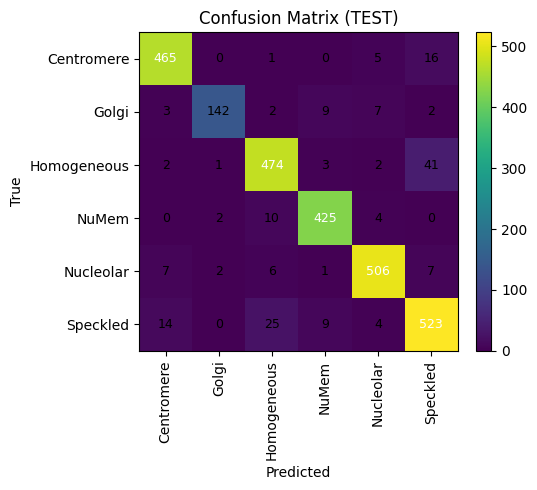

              precision    recall  f1-score   support

  Centromere     0.9470    0.9548    0.9509       487
       Golgi     0.9660    0.8606    0.9103       165
 Homogeneous     0.9151    0.9063    0.9107       523
       NuMem     0.9508    0.9637    0.9572       441
   Nucleolar     0.9583    0.9565    0.9574       529
    Speckled     0.8879    0.9096    0.8986       575

    accuracy                         0.9320      2720
   macro avg     0.9375    0.9253    0.9308      2720
weighted avg     0.9324    0.9320    0.9319      2720



In [12]:
# ===== Train AlexNet from scratch (AdamW, fixed LR=2e-4) + tqdm + test infer + confusion matrix =====
import time, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import confusion_matrix, classification_report

device = "cuda" if torch.cuda.is_available() else "cpu"
amp_enabled = (device == "cuda")
autocast_device = "cuda" if device == "cuda" else "cpu"

EPOCHS       = 100
LR           = 2e-4
WEIGHT_DECAY = 1e-4
CKPT_DIR     = Path("./ckpts_alexnet_scratch_adamw_fixedlr")
CKPT_DIR.mkdir(parents=True, exist_ok=True)

model = model.to(device)

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
scaler = torch.amp.GradScaler(enabled=amp_enabled)

def _batch_acc(logits: torch.Tensor, target: torch.Tensor) -> float:
    return (logits.argmax(1) == target).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, desc="Valid"):
    model.eval()
    total_loss, total_correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=desc, leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        with torch.autocast(device_type=autocast_device, enabled=amp_enabled):
            logits = model(xb)
            loss = criterion(logits, yb)
        total_loss   += loss.item() * xb.size(0)
        total_correct += (logits.argmax(1) == yb).sum().item()
        total        += xb.size(0)
        pbar.set_postfix(loss=f"{total_loss/total:.4f}",
                         acc=f"{(total_correct/total)*100:.2f}%",
                         lr=f"{optimizer.param_groups[0]['lr']:.2e}")
    return total_loss / total, total_correct / total

def plot_confusion_matrix(cm, classes, used="TEST", normalize=False):
    cm = np.asarray(cm)
    data = cm.astype(float)
    if normalize:
        row_sum = cm.sum(axis=1, keepdims=True).clip(min=1)
        data = data / row_sum

    fig_w = max(6, len(classes) * 0.8)
    fig_h = max(5, len(classes) * 0.6)
    fig, ax = plt.subplots(figsize=(fig_w, fig_h))
    im = ax.imshow(data, cmap="viridis")
    plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

    title = f"Confusion Matrix ({used})" + (" (row-normalized)" if normalize else "")
    ax.set_title(title)
    ax.set_xlabel("Predicted"); ax.set_ylabel("True")
    ax.set_xticks(np.arange(len(classes))); ax.set_yticks(np.arange(len(classes)))
    ax.set_xticklabels(list(le.classes_), rotation=90); ax.set_yticklabels(list(le.classes_))

    fmt = ".2f" if normalize else "d"
    thresh = data.max()/2.0 if data.size else 0.5
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            val_show = data[i, j] if normalize else cm[i, j]
            ax.text(j, i, format(val_show, fmt),
                    ha="center", va="center",
                    color="white" if data[i, j] > thresh else "black", fontsize=9)
    fig.tight_layout(); plt.show()

@torch.no_grad()
def test_infer_and_confusion(model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path):

    model.eval()
    used = "TEST"
    y_true, y_pred = [], []
    has_label_any = False

    pbar = tqdm(test_loader, desc="TestInfer", leave=False)
    for xb, rels in pbar:
        xb = xb.to(device, non_blocking=True)
        with torch.autocast(device_type=autocast_device, enabled=amp_enabled):
            logits = model(xb)
        preds = logits.argmax(1).cpu().tolist()

        for nm, pi in zip(rels, preds):
            from pathlib import Path as _P
            iid = extract_id_from_path(_P(nm))
            gt  = id2class.get(iid, None)
            if gt is not None:
                has_label_any = True
                y_true.append(int(le.transform([gt])[0]))
                y_pred.append(pi)

    if not has_label_any:
        used = "VAL"
        y_true, y_pred = [], []
        pbar = tqdm(val_loader, desc="ValInfer(fallback)", leave=False)
        for xb, yb in pbar:
            xb = xb.to(device, non_blocking=True)
            with torch.autocast(device_type=autocast_device, enabled=amp_enabled):
                logits = model(xb)
            preds = logits.argmax(1).cpu()
            y_true.append(yb.cpu().numpy()); y_pred.append(preds.numpy())
        y_true = np.concatenate(y_true) if y_true else np.array([])
        y_pred = np.concatenate(y_pred) if y_pred else np.array([])
    else:
        y_true = np.array(y_true); y_pred = np.array(y_pred)

    cm = confusion_matrix(y_true, y_pred, labels=list(range(NUM_CLASSES)))
    report = classification_report(
        y_true, y_pred,
        labels=list(range(NUM_CLASSES)),
        target_names=list(le.classes_),
        digits=4
    )
    acc_overall = (y_true == y_pred).mean() if len(y_true) else float("nan")
    return used, cm, report, acc_overall

best_acc = 0.0
t0_all = time.time()

for ep in range(1, EPOCHS + 1):
    model.train()
    running_loss, running_correct, seen = 0.0, 0, 0

    pbar = tqdm(train_loader, desc=f"Train {ep:03d}/{EPOCHS}", leave=False)
    for xb, yb in pbar:
        xb, yb = xb.to(device, non_blocking=True), yb.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)

        with torch.autocast(device_type=autocast_device, enabled=amp_enabled):
            logits = model(xb)
            loss = criterion(logits, yb)

        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=5.0)
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item() * xb.size(0)
        running_correct += (logits.detach().argmax(1) == yb).sum().item()
        seen += xb.size(0)

        tr_loss = running_loss / seen
        tr_acc  = running_correct / seen
        pbar.set_postfix(loss=f"{tr_loss:.4f}",
                         acc=f"{tr_acc*100:.2f}%",
                         lr=f"{optimizer.param_groups[0]['lr']:.2e}")

    val_loss, val_acc = evaluate(model, val_loader, desc="Valid")

    print(f"Epoch {ep:03d}/{EPOCHS} | "
          f"lr={optimizer.param_groups[0]['lr']:.6f} | "
          f"Train: loss {tr_loss:.4f} acc {tr_acc*100:.2f}% | "
          f"Val: loss {val_loss:.4f} acc {val_acc*100:.2f}%")

    # save last
    torch.save({
        "epoch": ep,
        "model_state": model.state_dict(),
        "optimizer_state": optimizer.state_dict(),
        "val_acc": val_acc,
    }, CKPT_DIR / "last.pt")

    # save best
    if val_acc > best_acc:
        best_acc = val_acc
        torch.save({
            "epoch": ep,
            "model_state": model.state_dict(),
            "optimizer_state": optimizer.state_dict(),
            "val_acc": best_acc,
        }, CKPT_DIR / "best.pt")
        print(f"  >> saved best.pt (val acc={best_acc*100:.2f}%)")

print(f"\nDone. Best val acc = {best_acc*100:.2f}% | total time = {time.time()-t0_all:.1f}s")

used, cm, report, acc_overall = test_infer_and_confusion(
    model, test_loader, val_loader, NUM_CLASSES, le, id2class, extract_id_from_path
)
print(f"[{used}] overall acc = {acc_overall:.4f}")
print(cm)
plot_confusion_matrix(cm, classes=list(le.classes_), used=used, normalize=False)
print(report)
